# DECIMA

See here for function documentation: https://genentech.github.io/decima/api/modules.html  

See here for applications: https://github.com/Genentech/decima-applications/tree/main/notebooks

See here for DECIMA VEP tutorial: https://github.com/Genentech/decima/blob/main/tutorials/2-variant-effect-prediction.ipynb

genvarloader tracks tutorial: https://gist.github.com/d-laub/4dc305158015f4f0d662f605243517f6

In [2]:
%load_ext autoreload
%autoreload 2

import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True
    


# import seqpro as sp
# import numpy as np 
# import genvarloader as gvl

# # Local code
# import src.genvarloader as GVL
# import src.vep_pipeline as vp
# import src.vep_analysis as va
# import src.clinvar as cv
import torch
import pooch
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
from tqdm import tqdm

import src.utils as utils
import src.GVL as GVL
import src.DECIMA as DC

 

/home/schilder/.conda/envs/decima/lib/python3.12/site-packages/sorted_nearest/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/home/schilder/.conda/envs/decima/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
from decima import DecimaResult
# Load default pre-trained model and metadata
result = DecimaResult.load()
result.load_model(
    model=0,
    device="cuda:0"
)


wandb: Downloading large artifact metadata:latest, 3122.32MB. 1 files... 


OSError: [Errno 28] No space left on device: '/home/schilder/.cache/wandb/artifacts/obj/md5/1d/bed5298efcc8f155dc7068d1a4dfa6' -> '/tmp/tmpz3zx2ock/metadata.h5ad'

In [ ]:
pd.set_option('display.max_rows', None)
result.cell_metadata["cell_type"].value_counts(dropna=False)[:10]

cell_type
fibroblast                         365
macrophage                         276
CD8-positive, alpha-beta T cell    259
CD4-positive, alpha-beta T cell    242
natural killer cell                230
B cell                             198
regulatory T cell                  196
classical monocyte                 187
Astrocyte                          185
Microglia                          181
Name: count, dtype: int64

In [ ]:
from decima.data.dataset import VariantDataset

df_variant = pd.read_table("https://github.com/Genentech/decima/raw/refs/heads/main/tutorials/data/variants.tsv")
print(df_variant.head())
dataset = VariantDataset(variants=df_variant) 

print("max_seq_shift:",dataset.max_seq_shift)
print("n_alleles:",dataset.n_alleles)
print("n_seqs:",dataset.n_seqs)
print("n_augmented:",dataset.n_augmented)
print("n_variants:",dataset.variants.shape[0])
print("padded_seq_len:",dataset.padded_seq_len)
print(dataset.variants.head())
dataset[0]

  chrom        pos  ref alt
0  chr1    1000018    G   A
1  chr1    1002308    T   C
2  chr1  109727471    A   C
3  chr1  109728286  TTT   G
4  chr1  109728807    T  GG


wandb: Downloading large artifact metadata:latest, 3122.32MB. 1 files... 
wandb:   1 of 1 files downloaded.  
Done. 0:0:1.7 (1838.0MB/s)


## Inference

In [5]:
col_map = { 
    "chrom": "chrom",
    "start": "chromStart",
    "end": "chromEnd", 
    "gene_type": "gene_type",
    "gene_biotype": "gene_biotype"
} 
bed = pl.from_pandas(result.gene_metadata.reset_index(names="gene_name")).rename(col_map)
bed = bed.with_columns(pl.col("chrom").cast(pl.Utf8)) 
bed.head()

NameError: name 'result' is not defined

In [4]:
ds_dict = DC.prepare_gvl_onekg(bed,  limit_chroms = ['chr6'])
ds_dict['chr6']

NameError: name 'bed' is not defined

In [ ]:
import pooch 
cohort = "1000_Genomes_on_GRCh38"
variant_set = "decima"
run_models = None
all_models = None
results_dir = None
site_filters = {}
window_len = DC.DECIMA_CONTEXT_SIZE
max_seqs_per_batch = None
limit_regions = None
limit_chroms = ['chr6']
limit_samples = None
limit_sites = None
force_gvl = False
force_vep = False
reverse_chroms = True
verbose = True
checkpoint_frequency = "site"
return_raw = False
device = "cuda"

import src.clinvar as cv   
import src.onekg as og
import genvarloader as gvl 
import numpy as np
 
  
bed = bed.with_columns(pl.col("chrom").cast(pl.Utf8))
    
# Merged fasta reference
# https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/technical/reference/GRCh38_reference_genome/GRCh38_full_analysis_set_plus_decoy_hla.fa
reference = pooch.retrieve(
    url=og.get_ftp_dict()[cohort]['ref'],
    known_hash=None,
    progressbar=True
)

manifest = og.list_remote_vcf(key=cohort)
chroms = manifest['chrom'].unique().tolist()
if reverse_chroms:
    chroms.reverse()

limit_chroms = utils.as_list(limit_chroms)
if isinstance(limit_chroms, list):
    limit_chroms = [str(chrom).replace("chr", "") for chrom in limit_chroms]
    chroms = [chrom for chrom in chroms if chrom.replace("chr", "") in limit_chroms]
    limit_chroms = None

# Only iterate over chromosomes that have variants
chroms = [chrom for chrom in chroms if chrom.replace("chr", "") in bed["chrom"].unique().str.replace("chr", "").to_list()]
if len(chroms)==0:
    raise ValueError("No chromosomes found in the BED file")

# Initialize raw results dictionary
if return_raw:
    raw_results = {}

# Iterate over chromosomes
for chrom in tqdm(chroms[:limit_chroms],
                    desc="Iterating over chromosomes"):
    
    # Create storage directory
    if results_dir is None:
        results_dir = os.path.join(os.path.expanduser('~'), 
                                "projects","data",cohort,variant_set)
    
    # Download VCF files
    vcf_paths = og.download_vcfs(key=cohort, 
                                 manifest=manifest.loc[manifest['chrom']==chrom,:],
                                 verbose=verbose>1)
    variants = vcf_paths[f"chr{chrom.replace('chr', '')}_vcf"]
    
    # Create GVL database name
    ds_path = os.path.join(results_dir, f"{chrom}.gvl")

    # Subset the BED file to the current chromosome
    bed_chrom = bed.filter(pl.col('chrom').str.replace("chr", "")==chrom.replace("chr", ""))
    
    if bed_chrom.height == 0:
        if verbose:
            print(f"No variants found for chromosome {chrom}")
        continue
    
    # Create GVL database
    if not os.path.exists(ds_path) or force_gvl:
        gvl.write(
            path=ds_path, 
            # Don't need to add gvl.with_length() bc bed already includes full window size
            bed=bed_chrom[:limit_regions],
            variants=variants,
            overwrite=True,
        )
    # Import GVL database
    ds = (
        gvl.Dataset.open(ds_path, reference=reference)
        .with_seqs("haplotypes")
        .with_len(window_len) 
    ) 

    # # Import sites_ds
    # # Convert BED to sites
    # sites_chrom = cv.bed_to_sites(bed_chrom)

    # # Create site_ds and site_ds_ref objects
    # try:
    #     site_ds = gvl.DatasetWithSites(ds, sites_chrom) 
    # except Exception as e:
    #     print(f"Error creating site_ds: {e}")
    #     continue

    # Create path for results file
    xr_ds_path = os.path.join(results_dir, f"{chrom}.zarr") 
    
    # Run VEP pipeline
    break
    


21:22:06 | INFO | Writing dataset to /home/schilder/projects/data/1000_Genomes_on_GRCh38/decima/chr6.gvl
21:22:06 | INFO | Using 2548 samples.
21:22:06 | INFO | Writing genotypes.
21:22:06 | INFO | Loading genoray index.


In [6]:
import torch
import src.DECIMA as DC

models = DC.load_decima_models(device="cuda") 

wandb: Downloading large artifact rep0:latest, 720.03MB. 1 files... 
wandb:   1 of 1 files downloaded.  
Done. 0:0:0.6 (1298.4MB/s)
wandb: Downloading large artifact rep1:latest, 720.03MB. 1 files... 
wandb:   1 of 1 files downloaded.  
Done. 0:0:0.5 (1333.2MB/s)
wandb: Downloading large artifact rep2:latest, 720.03MB. 1 files... 
wandb:   1 of 1 files downloaded.  
Done. 0:0:0.6 (1249.9MB/s)
wandb: Downloading large artifact rep3:latest, 720.03MB. 1 files... 
wandb:   1 of 1 files downloaded.  
Done. 0:0:0.6 (1281.9MB/s)


In [7]:
# # Limit appears to be 16 sequences at a time (8 samples x 2 ploidy)

# for batch_size in range(10, ds.n_samples+1, 1):
#     print(f"Running prediction for batch_size={batch_size}")
    
#     # Prepare input
#     ohe_with_tracks = DC.gvl_to_decima_input(ds, regions=0, samples=range(batch_size//2))
    
#     # Run prediction
#     preds = DC.ensemble_mean_predict(
#         models=models, 
#         sequence_one_hot=ohe_with_tracks.to(dtype=torch.float32)
#     )

#     # Only assign samples if successful
#     samples = np.repeat(ds.samples[0:batch_size//2], 2)
#     print(f"Predictions shape for batch_size={batch_size}: {preds.shape}")
#     torch.cuda.empty_cache()


In [8]:
seqs =GVL.stack_ploidy(ds[0,])
print(seqs.shape)

(5096, 524288)


In [9]:
variants

'/home/schilder/projects/data/1000_Genomes_on_GRCh38/vcf/ALL.chrX.shapeit2_integrated_snvindels_v2a_27022019.GRCh38.phased.vcf.gz'

In [21]:
variable_genes = {x:i for i,x in enumerate(ds.regions["gene_name"]) if x.startswith("HLA")}
variable_genes

{}

In [32]:
len(regions["gene_name"].unique().sort().to_list())

639

In [27]:
regions = ds.regions.with_row_index()
regions.filter(pl.col("gene_name").str.starts_with("HLA"))

index,gene_name,chrom,chromStart,chromEnd,strand,gene_type,frac_nan,mean_counts,n_tracks,gene_start,gene_end,gene_length,gene_mask_start,gene_mask_end,frac_N,fold,dataset,gene_id,pearson,size_factor_pearson,ensembl_canonical_tss
u32,str,str,i64,i64,cat,cat,f64,f64,i64,i64,i64,i64,i64,i64,f64,cat,cat,str,f64,f64,f64


In [19]:
ds.regions[list(variable_genes.values())[0]]

gene_name,chrom,chromStart,chromEnd,strand,gene_type,frac_nan,mean_counts,n_tracks,gene_start,gene_end,gene_length,gene_mask_start,gene_mask_end,frac_N,fold,dataset,gene_id,pearson,size_factor_pearson,ensembl_canonical_tss
str,str,i64,i64,cat,cat,f64,f64,i64,i64,i64,i64,i64,i64,f64,cat,cat,str,f64,f64,f64
"""IRS4""","""chrX""",108375961,108900249,"""-""","""protein_coding""",0.183033,0.04798,1260,108732482,108736409,3927,163840,167767,0.0,"""['fold2']""","""train""","""ENSG00000133124""",0.372825,0.202354,1.08736563e8


In [ ]:
# Define batch size for processing
regions = list(variable_genes.values())[0]
batch_size = 10  # or any suitable batch size
all_preds = [] 
batches = utils.split_batches(samples=ds.samples, max_seqs_per_batch=batch_size)
max_batches = 10
for batch_samples in tqdm(batches[:max_batches], desc="Processing batches"):
    # print(f"Processing samples {batch_samples}")
    # Prepare input for this batch
    ohe_with_tracks = DC.gvl_to_decima_input(ds, regions=regions, samples=batch_samples)
    # Run prediction
    preds = DC.ensemble_mean_predict(
        models=models, 
        sequence_one_hot=ohe_with_tracks.to(dtype=torch.float32)
    )
    all_preds.append(preds.cpu())
    # Assign samples for this batch
    samples = np.repeat(batch_samples, 2) 

    # Clean up
    del ohe_with_tracks, preds
    torch.cuda.empty_cache()

# Concatenate all predictions if needed
final_preds = torch.cat(all_preds, dim=0)  # adjust dim as needed

Processing batches: 100%|██████████| 10/10 [01:39<00:00,  9.92s/it]


In [23]:
inds = None
ohe_with_tracks = DC.gvl_to_decima_input(ds, regions=regions, samples=batch_samples)
sequence_one_hot=ohe_with_tracks.to(dtype=torch.float32)
with torch.no_grad():
    preds = []
    for model_i in models:
        pred = model_i(sequence_one_hot.to(device))
        break
        pred = torch.mean(pred[:,inds,:],dim=1)
        preds.append(pred)
    
    # preds = torch.mean(torch.stack(preds), dim=0)

In [30]:
pred.shape

torch.Size([10, 8856, 1])

In [29]:
torch.mean(pred[:,inds,:],dim=1).shape

torch.Size([10, 8856, 1])

In [26]:
pred.squeeze().unique(dim=0).shape

torch.Size([1, 8856])

In [15]:
samples  = np.repeat([b for b in batches[:max_batches] for b in b], 2)
df = pd.concat([pd.DataFrame(torch.cat(all_preds, dim=0).squeeze().cpu().numpy().T, columns=samples), 
               result.cell_metadata.reset_index(names="id")], axis=1)
df.head() 

,HG00096,HG00096,HG00097,HG00097,HG00099,HG00099,HG00100,HG00100,HG00101,HG00101,...,region,subregion,celltype_coarse,n_cells,total_counts,n_genes,size_factor,train_pearson,val_pearson,test_pearson
0,0.808087,0.808087,0.808087,0.808087,0.808087,0.808087,0.808087,0.808087,0.808087,0.808087,...,Amygdala,Amygdala,NaN,331,15928830.0,17000,41431.465186,0.942459,0.841377,0.865640
1,0.949676,0.949676,0.949676,0.949676,0.949676,0.949676,0.949676,0.949676,0.949676,0.949676,...,Amygdala,Basolateral nuclear group (BLN) - lateral nucl...,NaN,11369,295213300.0,18080,40765.341481,0.943098,0.838936,0.861092
2,0.985807,0.985807,0.985807,0.985807,0.985807,0.985807,0.985807,0.985807,0.985807,0.985807,...,Amygdala,Bed nucleus of stria terminalis and nearby - BNST,NaN,139,2593231.0,15418,42556.387020,0.952170,0.854544,0.866654
3,1.051771,1.051771,1.051771,1.051771,1.051771,1.051771,1.051771,1.051771,1.051771,1.051771,...,Amygdala,Central nuclear group - CEN,NaN,3892,99463712.0,17959,42884.641430,0.959744,0.863585,0.881554
4,0.976990,0.976990,0.976990,0.976990,0.976990,0.976990,0.976990,0.976990,0.976990,0.976990,...,Amygdala,Corticomedial nuclear group (CMN) - anterior c...,NaN,2945,128161939.0,17885,41816.741933,0.951365,0.854304,0.868902


In [ ]:
torch.cat(all_preds, dim=0).squeeze().unique(dim=0).shape

torch.Size([1, 8856])

## Attributions

In [ ]:
# Perform attribution analysis
attributions = result.attributions( 
    gene="SPI1",
    tasks='cell_type == "classical monocyte"',
)

In [14]:
print(attributions.chrom, attributions.end, attributions.start)

print(attributions.gene, attributions.gene_start, attributions.gene_end,",",attributions.gene_mask_start, attributions.gene_mask_end)

print(attributions.fasta_str())

print(attributions.attrs)

chr11 47542416 47018128
SPI1 47378576 47378576 , 163840 163840
>SPI1
...

[[-0.0000000e+00 -0.0000000e+00 -0.0000000e+00 ... -0.0000000e+00
   0.0000000e+00  0.0000000e+00]
 [-0.0000000e+00 -0.0000000e+00 -2.8582457e-05 ...  0.0000000e+00
   0.0000000e+00  0.0000000e+00]
 [-0.0000000e+00  1.4564113e-04  0.0000000e+00 ...  5.6269462e-05
  -0.0000000e+00  2.4767707e-05]
 [ 2.0194495e-04 -0.0000000e+00  0.0000000e+00 ... -0.0000000e+00
   2.0039392e-05 -0.0000000e+00]]


In [15]:
attributions.from_seq()

TypeError: Attribution.from_seq() missing 1 required positional argument: 'inputs'

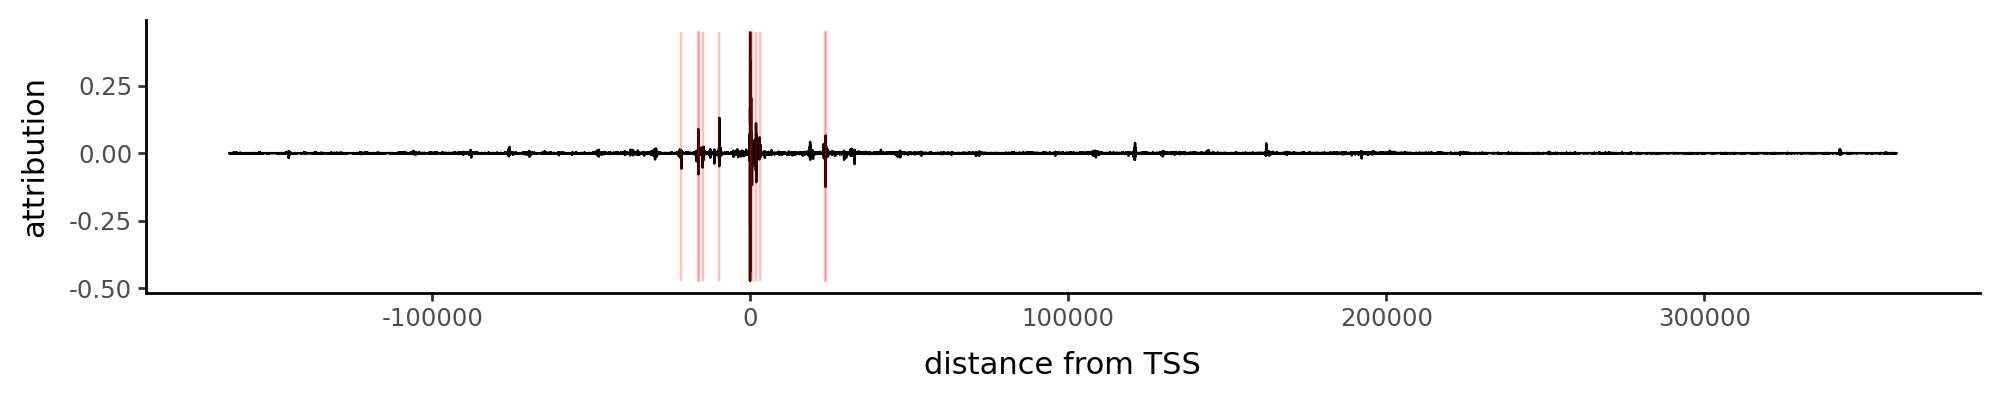

In [17]:
attributions.plot_peaks()

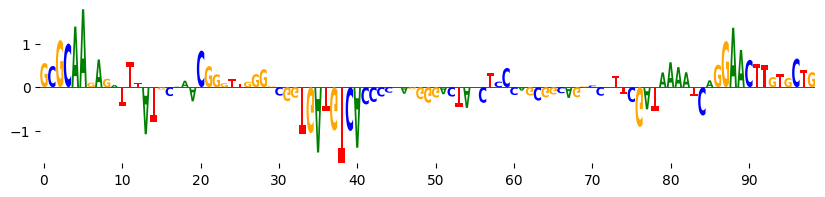

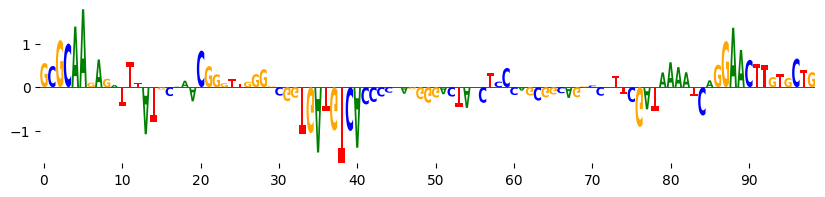

In [20]:
attributions.plot_seqlogo()
plt.show()